In [177]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 300

In [181]:
import os
from pathlib import Path
from dataclasses import dataclass
### LOAD THAT DATA TWIN ###
@dataclass
class SimData:
    q1: np.ndarray      # (n_frames, N) - phi
    q2: np.ndarray      # (n_frames, N) - theta
    theta: np.ndarray   # (n_frames, N) - orientation

def load(path: Path, frames=None) -> SimData:
    with h5py.File(path, 'r') as f:
        sl = frames if frames is not None else slice(None)
        return SimData(
            q1    = np.asarray(f['state/q1'])[sl],
            q2    = np.asarray(f['state/q2'])[sl],
            theta = np.asarray(f['state/theta'])[sl]
        )
    
date = '2026-04-28_16-25-59'
data_dir = Path('../data') / Path(date)
manifolds = ['sphere', 'torus', 'euclidean']
ds, cs, ss = [0.0, 0.2, 1.0, 5.0], [0.0, 0.2, 1.0, 5.0], [10, 20, 30]

manifold = manifolds[2]
d = ds[1]
c = cs[3]
s = ss[2]

dataset = f'd{d}_c{c}_s{s}.h5'

file_path = data_dir / manifold / dataset

data = load(file_path)


### Opening files

In [171]:
print(data.theta.shape)  # (10000, 250)
print(data.theta[0].shape)    # (all particles theta at t = 0)
print(data.theta.T[0].shape)  # (theta timeseries for particle 0)

(2000, 250)
(250,)
(2000,)


In [172]:
steps= data.theta.shape[0]
N = data.theta.shape[1]

print("steps =",steps)
print("N =",N)

steps = 2000
N = 250


### Global order parameter with 3-vectors

In [121]:
def coordinate_unit_vectors(q1, q2, manifold):
    if manifold == 'sphere':
        e1_hat = np.array([-np.sin(q1), np.cos(q1), np.zeros_like(q1)])
        e2_hat = np.array([np.cos(q1)*np.cos(q2), np.sin(q1)*np.cos(q2), -np.sin(q2)])
    elif manifold == 'torus':
        e1_hat = np.array([-np.sin(q1), np.cos(q1), np.zeros_like(q1)])
        e2_hat = np.array([-np.cos(q1)*np.sin(q2), -np.sin(q1)*np.sin(q2), np.cos(q2)*np.ones_like(q1)])
    else:
        e1_hat = np.array([np.ones_like(q1), np.zeros_like(q1), np.zeros_like(q1)])
        e2_hat = np.array([np.zeros_like(q1), np.ones_like(q1), np.zeros_like(q1)])
    return e1_hat, e2_hat  # each (3, 10000, 250)

def compute_heading_vectors(q1, q2, theta, manifold):
    e1_hat, e2_hat = coordinate_unit_vectors(q1, q2, manifold)
    return np.cos(theta)*e1_hat + np.sin(theta)*e2_hat  # (3, 10000, 250)

In [122]:
v = compute_heading_vectors(data.q1, data.q2, data.theta, manifold)

In [123]:
def order_parameter(heading_vectors, warmup):
    # heading_vectors: (3, 10000, 250)
    mean_v = np.mean(heading_vectors, axis=2)  # (3, 10000) - mean over particles
    order_parameter = np.linalg.norm(mean_v, axis=0)        # (10000,) - norm over xyz
    return np.mean(order_parameter[warmup:])

In [124]:
results = {}

for manifold in manifolds:
    for d in ds:
        for c in cs:
            for s in ss:
                dataset = f'd{d}_c{c}_s{s}.h5'
                data = load(data_dir / manifold / dataset)
                
                v = compute_heading_vectors(data.q1, data.q2, data.theta, manifold)
                
                results[(manifold, d, c, s)] = order_parameter(v, warmup = int(0.5*steps))

In [125]:
phi_avg = {}

# average over random seeds
for manifold in manifolds:
    for d in ds:
        for c in cs:
            phi_avg[(manifold, d, c)] = np.mean([results[(manifold, d, c, s)] for s in ss])

In [126]:
def generate_plot_title(manifold, N, steps):
    return f"Order Parameter on {manifold.capitalize()}.\n{N} particles over {steps} timesteps"

In [127]:
import scienceplots
plt.style.use('science')

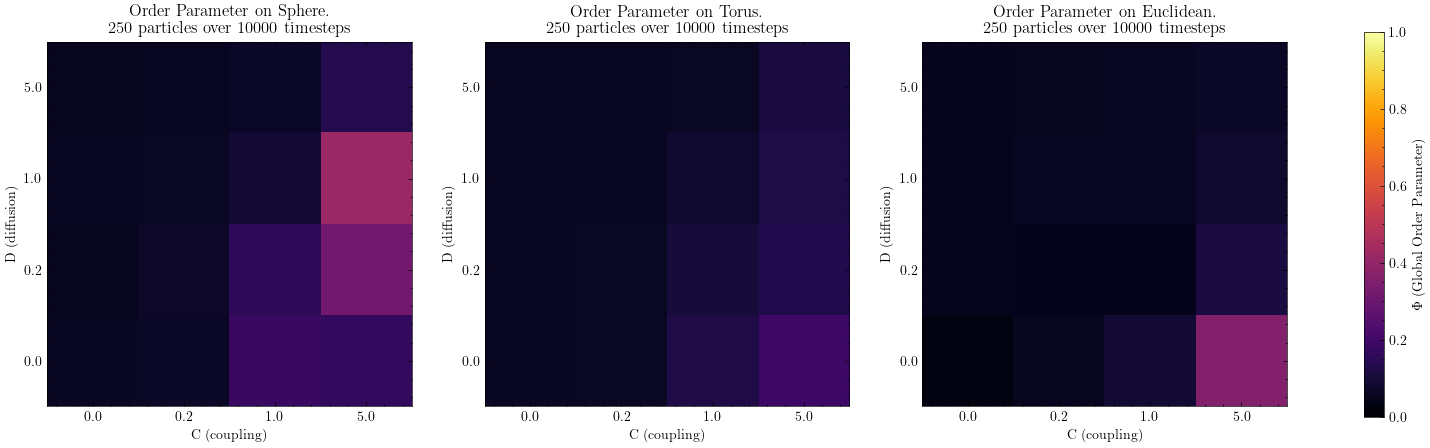

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, manifold in zip(axes, manifolds):
    phi_grid = np.zeros((len(ds), len(cs)))
    for i, d in enumerate(ds):
        for j, c in enumerate(cs):
            phi_grid[i, j] = phi_avg[(manifold, d, c)]

    im = ax.imshow(phi_grid, origin='lower', cmap='inferno', vmin=0, vmax=1.0)
    ax.set_xticks(range(len(cs)))
    ax.set_xticklabels(cs)
    ax.set_yticks(range(len(ds)))
    ax.set_yticklabels(ds)
    ax.set_xlabel('C (coupling)')
    ax.set_ylabel('D (diffusion)')
    ax.set_title(generate_plot_title(manifold, N, steps))

fig.colorbar(im, ax=axes, label=r'$\Phi$ (Global Order Parameter)')
plt.show()

### Order parameter with tangent spaces + parallel transport

In [173]:
def order_parameter_intrinsic(q1, q2, theta, warmup, manifold, R=1, r=1/np.pi):
    if manifold == 'sphere':
        theta_transported = theta - q1
    elif manifold == 'torus':
        psi_mean = np.mean(q2, axis=1, keepdims=True)
        correction = np.sin(psi_mean) * r / (R + r * np.cos(psi_mean)) * q1
        theta_transported = theta - correction
    else:
        theta_transported = theta
    
    mean_cos = np.mean(np.cos(theta_transported), axis=1)
    mean_sin = np.mean(np.sin(theta_transported), axis=1)
    phi = np.sqrt(mean_cos**2 + mean_sin**2)
    
    return np.mean(phi[warmup:])

In [174]:
results_intrinsic = {}

for manifold in manifolds:
    for d in ds:
        for c in cs:
            for s in ss:
                dataset = f'd{d}_c{c}_s{s}.h5'
                data = load(data_dir / manifold / dataset)
                
                results_intrinsic[(manifold, d, c, s)] = order_parameter_intrinsic(
                    data.q1, data.q2, data.theta, warmup=int(0.5*steps), manifold=manifold
                )

phi_avg_intrinsic = {}
for manifold in manifolds:
    for d in ds:
        for c in cs:
            phi_avg_intrinsic[(manifold, d, c)] = np.mean([results_intrinsic[(manifold, d, c, s)] for s in ss])

In [175]:
def generate_plot_title2(manifold, N, steps):
    return f"Intrinsic Order Parameter on {manifold.capitalize()}.\n{N} particles over {steps} timesteps"

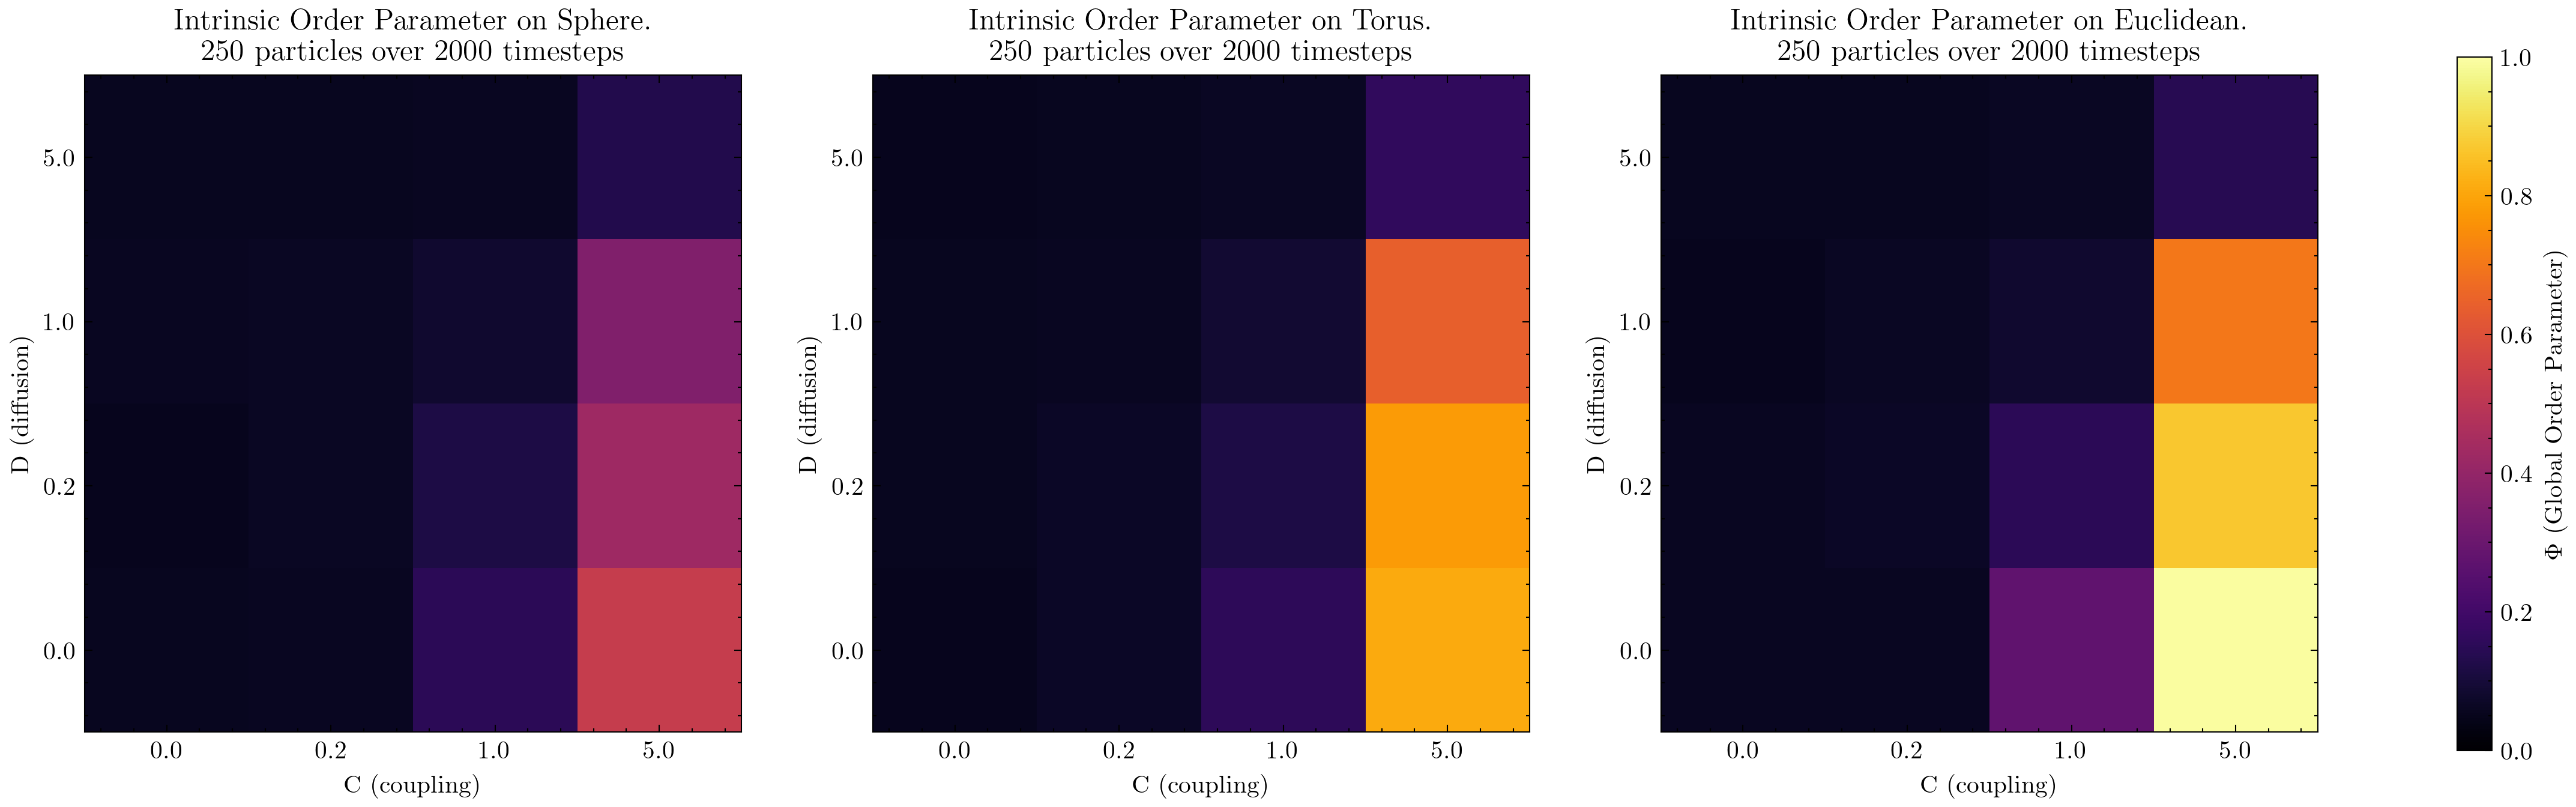

In [182]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, manifold in zip(axes, manifolds):
    phi_grid = np.zeros((len(ds), len(cs)))
    for i, d in enumerate(ds):
        for j, c in enumerate(cs):
            phi_grid[i, j] = phi_avg_intrinsic[(manifold, d, c)]

    im = ax.imshow(phi_grid, origin='lower', cmap='inferno', vmin=0, vmax=1)
    ax.set_xticks(range(len(cs)))
    ax.set_xticklabels(cs)
    ax.set_yticks(range(len(ds)))
    ax.set_yticklabels(ds)
    ax.set_xlabel('C (coupling)')
    ax.set_ylabel('D (diffusion)')
    ax.set_title(generate_plot_title2(manifold, N, steps))

fig.colorbar(im, ax=axes, label=r'$\Phi$ (Global Order Parameter)')


def save_num(date):
    if date == '2026-04-27_23-57-25':
        return 1
    elif date == '2026-04-28_16-25-59':
        return 2
    elif date == '2026-04-29_10-44-40':
        return 3

plt.savefig(f'../../non-repo/Final Presentation/figures/int_order{save_num(date)}.png', dpi=300, bbox_inches='tight')
plt.show()